<a href="https://colab.research.google.com/github/DevLass/TurismoBrasil/blob/main/TurismoBrasil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('chegadas_2024.csv', encoding='latin-1', sep=';')
df.head()

,Continente,cod continente,País,cod pais,UF,cod uf,Via,cod via,ano,Mês,cod mes,Chegadas
0,Europa,6,Alemanha,57,Outras Unidades da Federação,99,Aérea,1,2024,Janeiro,1,10
1,América do Sul,4,Argentina,26,Outras Unidades da Federação,99,Aérea,1,2024,Janeiro,1,1197
2,Europa,6,Bélgica,59,Outras Unidades da Federação,99,Aérea,1,2024,Janeiro,1,3
3,América do Norte,3,Canadá,23,Outras Unidades da Federação,99,Aérea,1,2024,Janeiro,1,2
4,América do Sul,4,Chile,28,Outras Unidades da Federação,99,Aérea,1,2024,Janeiro,1,1


In [43]:
# Possíveis Ações
# Limpar os Dados, já que nessa situação Cod Continente, Pais, UF, VIa e Mês / Ano não tem utilidade aqui (Feito)
# Verificar a existência de nulos e trata-los (Feito)

# Analises
# Continente x Chegada (Feito)
# Pais x Chegada (Feito)
# Via x Chegada (Feito)
# Mês x Chegada (Grafico de Linhas) (Feito)
# Continente x Via (Feito)
# Continente x Chegada x Mês (Feito)


In [44]:
# Visualização Limpa e Adequada ao Escopo atual
df_turismo = df[['Continente', 'País', 'cod pais', 'Via', 'Mês', 'Chegadas']]
df_turismo.head()

,Continente,País,cod pais,Via,Mês,Chegadas
0,Europa,Alemanha,57,Aérea,Janeiro,10
1,América do Sul,Argentina,26,Aérea,Janeiro,1197
2,Europa,Bélgica,59,Aérea,Janeiro,3
3,América do Norte,Canadá,23,Aérea,Janeiro,2
4,América do Sul,Chile,28,Aérea,Janeiro,1


In [45]:
# Não temos Nulos
df_turismo.isna().sum()

,0
Continente,0
País,0
cod pais,0
Via,0
Mês,0
Chegadas,0


In [46]:
df_continente_chegadas = df[['Continente', 'Chegadas']]
df_continente_chegadas.groupby('Continente').sum().sort_values('Chegadas')

,Chegadas
Continente,
Continente não especificado,56
África,55331
Oceania,64033
América Central e Caribe,67715
Ásia,256276
América do Norte,924214
Europa,1482166
América do Sul,3923828


<Axes: ylabel='Continente'>

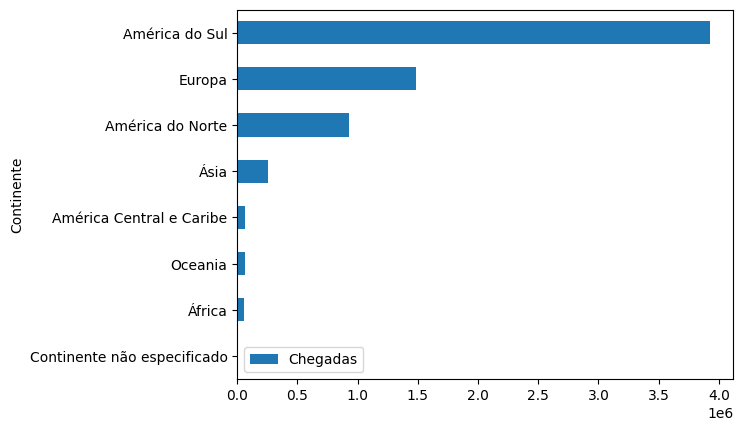

In [47]:
df_continente_chegadas.groupby('Continente').sum().sort_values('Chegadas').plot(kind='barh')

In [48]:
df_pais_chegadas = df[['País', 'Chegadas']]
df_pais_chegadas.groupby('País').sum().sort_values('Chegadas')

,Chegadas
País,
Guiana Francesa,4
Países não especificados,56
Outros países da Oceania,115
Cabo Verde,568
Síria,588
...,...
Uruguai,388464
Paraguai,465020
Chile,653895


<Axes: ylabel='País'>

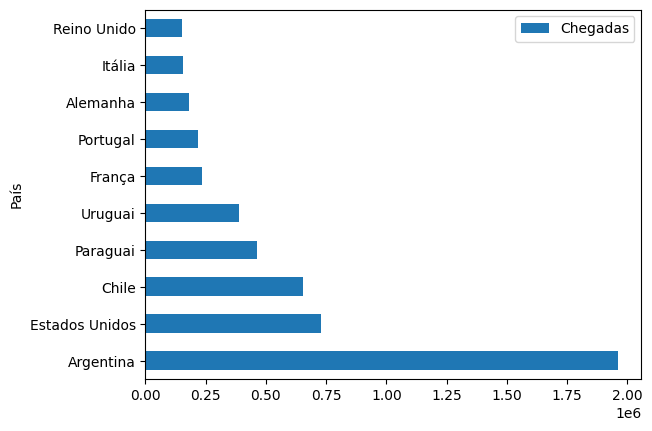

In [49]:
df_pais_chegadas.groupby('País').sum().sort_values('Chegadas', ascending=False).head(10).plot(kind='barh')

In [53]:
df_via_chegadas = df[['Via', 'Chegadas']]
df_via_chegadas.groupby('Via').sum().sort_values('Chegadas')

,Chegadas
Via,
Fluvial,93880
Marítima,140570
Terrestre,1934823
Aérea,4604346


<Axes: ylabel='Chegadas'>

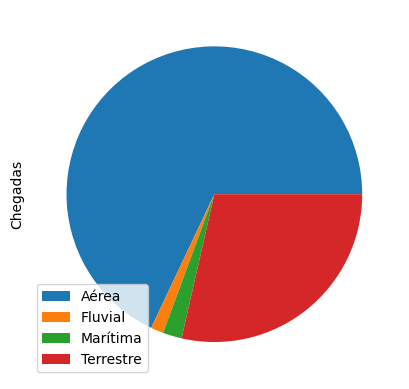

In [56]:
df_via_chegadas.groupby('Via').sum().plot(kind='pie', y='Chegadas', labels=None)

In [66]:

ordem_meses = ['Janeiro', 'Fevereiro', 'Março', 'Abril', 'Maio', 'Junho',
               'Julho', 'Agosto', 'Setembro', 'Outubro', 'Novembro', 'Dezembro']

df_mes_chegadas = df[['Mês', 'Chegadas']].copy()
df_mes_chegadas['Mês'] = pd.Categorical(df_mes_chegadas['Mês'], categories=ordem_meses, ordered=True)

df_mes_chegadas = df_mes_chegadas.groupby('Mês').sum().sort_values('Mês')

df_mes_chegadas.head(12)


<ipython-input-66-7fdb81b95806>:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,Chegadas
Mês,
Janeiro,956737
Fevereiro,833306
Março,740483
Abril,398587
Maio,335652
Junho,332474
Julho,437103
Agosto,417940
Setembro,445389


<Axes: xlabel='Mês'>

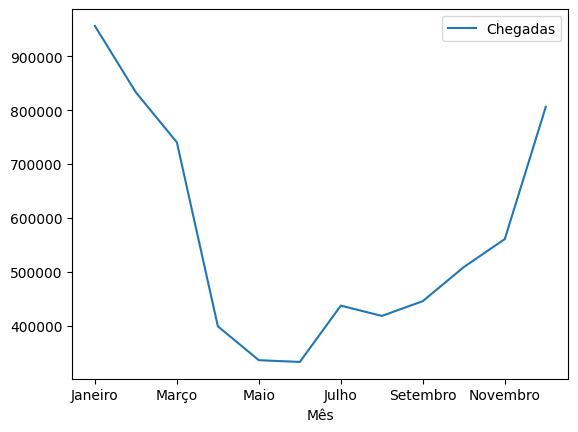

In [64]:
df_mes_chegadas.plot(kind='line')

In [77]:
df.groupby(['Continente', 'Via'])['Chegadas'].sum().unstack(fill_value=0)

Via,Aérea,Fluvial,Marítima,Terrestre
Continente,,,,
América Central e Caribe,61467,102,435,5711
América do Norte,848756,4993,15296,55169
América do Sul,2052345,80144,93799,1697540
Continente não especificado,38,2,5,11
Europa,1304726,8264,25410,143766
Oceania,55015,125,770,8123
África,53979,120,456,776
Ásia,228020,130,4399,23727


<Axes: ylabel='Continente'>

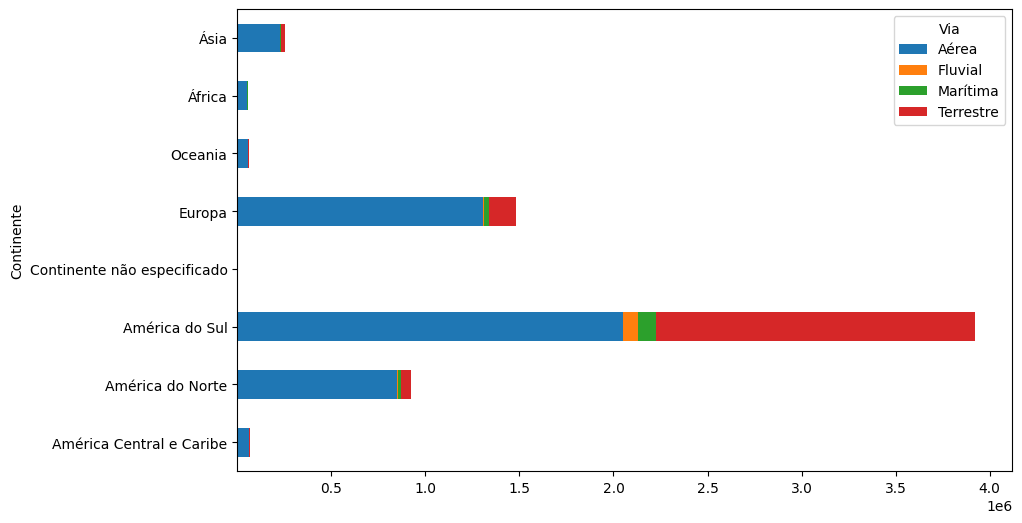

In [76]:
df.groupby(['Continente', 'Via'])['Chegadas'].sum().unstack(fill_value=0).plot(kind='barh', stacked=True, figsize=(10,6))




In [80]:
df.groupby(['Continente', 'Mês'])['Chegadas'].sum().unstack(fill_value=0)

Mês,Abril,Agosto,Dezembro,Fevereiro,Janeiro,Julho,Junho,Maio,Março,Novembro,Outubro,Setembro
Continente,,,,,,,,,,,,
América Central e Caribe,5159,6276,6579,3797,3633,4857,5221,5128,5727,6942,7143,7253
América do Norte,63179,69764,108086,86994,66633,65816,68453,60163,104576,88219,71069,71262
América do Sul,197391,188794,473092,534411,735052,229980,166554,169745,426580,278994,277818,245417
Continente não especificado,9,4,4,5,10,3,2,0,6,4,4,5
Europa,102578,123438,185560,170635,122699,110749,66839,72343,163396,150613,122029,91287
Oceania,4049,3360,7380,7841,7169,3677,3101,3068,8816,5543,5137,4892
África,4572,5402,5359,3937,3394,4094,4301,4415,4494,5551,5089,4723
Ásia,21650,20902,20418,25686,18147,17927,18003,20790,26888,24866,20449,20550


<ipython-input-87-5bb2120a384e>:6: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



<Axes: xlabel='Mês'>

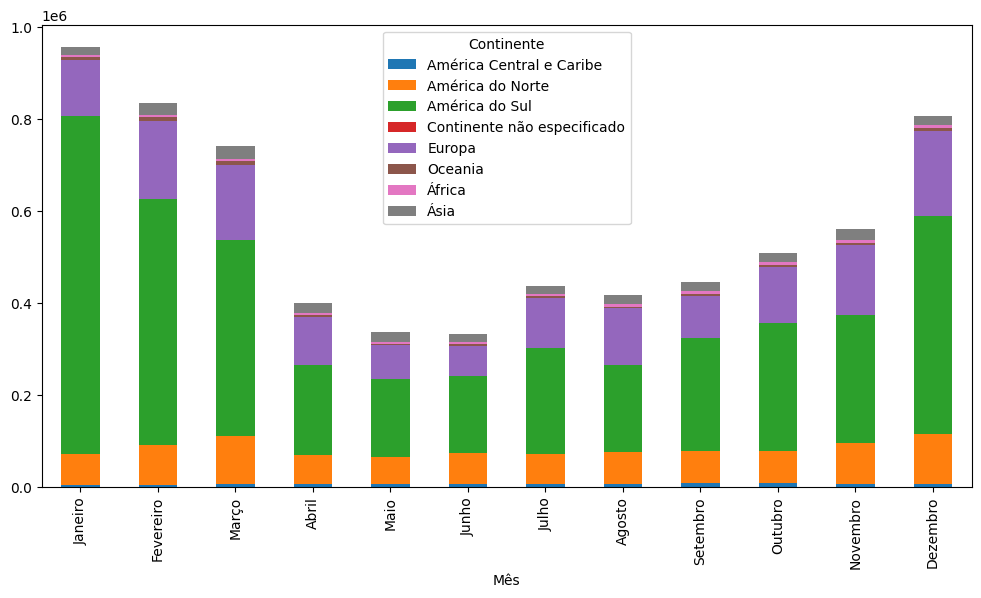

In [87]:
ordem_meses = ['Janeiro', 'Fevereiro', 'Março', 'Abril', 'Maio', 'Junho',
               'Julho', 'Agosto', 'Setembro', 'Outubro', 'Novembro', 'Dezembro']

df['Mês'] = pd.Categorical(df['Mês'], categories=ordem_meses, ordered=True)

df_mes_continente = df.groupby(['Mês', 'Continente'])['Chegadas'].sum().unstack(fill_value=0)

df_mes_continente = df_mes_continente.sort_index()

df_mes_continente.plot(kind='bar', stacked=True, figsize=(12, 6))
